# 12 Enzyme-Polymer Analysis

Analyse one enzyme-polymer GROMACS production run. The first question uses protein backbone RMSD, protein-aligned polymer RMSD, and Total Energy diagnostics to judge whether more simulation may be needed. Catalytic triad-polymer contact analysis is kept as a separate later section.

## 1. Title and purpose

This notebook is intended for a single completed GROMACS production run. It keeps the analysis focused on:

1. Whether protein RMSD, polymer motion relative to the protein, and Total Energy diagnostics suggest that the current trajectory is sufficient or should be extended.
2. Catalytic triad-polymer head/main/tail minimum distances and contact occupancy as a separate contact question.

## 2. Path configuration

In [1]:
from pathlib import Path
import shutil
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from iphasimulator.naming import oligomer_name

POLYMER_SYSTEM = oligomer_name("3HO", 4)
SYSTEM_NAME = f"GK13_{POLYMER_SYSTEM}"
SYSTEM_DIR = Path("/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme") / f"{SYSTEM_NAME}_gromacs"

XTC_PATH = SYSTEM_DIR / "production_combined_003.xtc"
EDR_PATH = SYSTEM_DIR / "production_combined_003.edr"
GRO_PATH = SYSTEM_DIR / "step6.2_npt.gro"
TPR_PATH = SYSTEM_DIR / "step6.2_npt.tpr"

OUTPUT_DIR = SYSTEM_DIR / "analysis" / "enzyme_polymer_analysis"

CUTOFF_ANGSTROM = 3.0
POLYMER_SELECTION = "resname LIG"

POLYMER_HEAD_RESIDS = None
POLYMER_MAIN_RESIDS = None
POLYMER_TAIL_RESIDS = None

paths = {
    "system_dir": SYSTEM_DIR,
    "trajectory_xtc": XTC_PATH,
    "energy_edr": EDR_PATH,
    "structure_gro": GRO_PATH,
    "topology_tpr": TPR_PATH,
    "output_dir": OUTPUT_DIR,
}

for label, path in paths.items():
    print(f"{label:16s} {path}")

system_dir       /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs
trajectory_xtc   /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/production_combined_003.xtc
energy_edr       /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/production_combined_003.edr
structure_gro    /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step6.2_npt.gro
topology_tpr     /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step6.2_npt.tpr
output_dir       /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis


## 3. File checks

In [2]:
required_files = {
    "XTC_PATH": XTC_PATH,
    "EDR_PATH": EDR_PATH,
    "GRO_PATH": GRO_PATH,
}

file_check = pd.DataFrame(
    [
        {"label": label, "path": str(path), "exists": path.exists()}
        for label, path in {**required_files, "TPR_PATH": TPR_PATH}.items()
    ]
)
display(file_check)

missing = [f"{label}: {path}" for label, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required input file(s):\n" + "\n".join(missing))

if not TPR_PATH.exists():
    print(f"TPR_PATH was not found. MDAnalysis will use GRO_PATH as the topology: {GRO_PATH}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

,label,path,exists
0,XTC_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True
1,EDR_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True
2,GRO_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True
3,TPR_PATH,/Users/k20098771/Data/MD_projects/PHA/MD_data/...,True


Output directory: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis


## 4. Total Energy diagnostic

Total Energy is only a first diagnostic. In NVT/NPT, it is not expected to be perfectly conserved, but strong drift or sudden jumps suggest a problem. The plot overlays a cumulative frame mean: at each frame, the mean includes all energy values from the first frame through the current frame.

The extraction uses GROMACS `gmx energy` and selects only Total Energy. The notebook first tries `Total-Energy`, then retries with `Total Energy` if needed. GROMACS reports the energy time in picoseconds; the notebook converts it to nanoseconds for plotting and CSV export.

Equivalent shell command for the first attempt:

```bash
printf "Total-Energy\n0\n" | gmx energy -f step7_production.edr -o total_energy.xvg
```

In [3]:
TOTAL_ENERGY_XVG = OUTPUT_DIR / "total_energy.xvg"
TOTAL_ENERGY_CSV = OUTPUT_DIR / "total_energy.csv"
TOTAL_ENERGY_PNG = OUTPUT_DIR / "total_energy.png"

GMX_EXECUTABLE = shutil.which("gmx") or shutil.which("gmx_mpi")
if GMX_EXECUTABLE is None:
    raise RuntimeError("Could not find `gmx` or `gmx_mpi` on PATH. Load GROMACS before running this cell.")
if not EDR_PATH.exists():
    raise FileNotFoundError(f"Energy file does not exist: {EDR_PATH}")
if EDR_PATH.suffix.lower() != ".edr":
    raise ValueError(f"EDR_PATH must point to a .edr file, not: {EDR_PATH}")

print(f"GROMACS executable: {GMX_EXECUTABLE}")
print(f"Energy input: {EDR_PATH.resolve()}")


def run_gmx_energy(selection_name: str) -> subprocess.CompletedProcess:
    if TOTAL_ENERGY_XVG.exists():
        TOTAL_ENERGY_XVG.unlink()

    command = [
        GMX_EXECUTABLE,
        "energy",
        "-f",
        str(EDR_PATH),
        "-o",
        str(TOTAL_ENERGY_XVG),
    ]
    return subprocess.run(
        command,
        input=f"{selection_name}\n0\n",
        text=True,
        capture_output=True,
        cwd=OUTPUT_DIR,
        check=False,
    )


attempts = []
energy_selection = None
for candidate in ("Total-Energy", "Total Energy"):
    result = run_gmx_energy(candidate)
    attempts.append((candidate, result.returncode, result.stdout, result.stderr))
    if result.returncode == 0 and TOTAL_ENERGY_XVG.exists() and TOTAL_ENERGY_XVG.stat().st_size > 0:
        energy_selection = candidate
        break

if energy_selection is None:
    details = []
    for candidate, returncode, stdout, stderr in attempts:
        details.append(
            f"Selection: {candidate}\n"
            f"Return code: {returncode}\n"
            f"STDOUT:\n{stdout}\n"
            f"STDERR:\n{stderr}"
        )
    raise RuntimeError("gmx energy failed for both Total-Energy and Total Energy.\n\n" + "\n\n".join(details))

print(f"Extracted GROMACS energy term: {energy_selection}")
print(f"Wrote: {TOTAL_ENERGY_XVG}")


def read_xvg_two_column(path: Path) -> pd.DataFrame:
    rows = []
    with path.open() as handle:
        for line in handle:
            stripped = line.strip()
            if not stripped or stripped.startswith(("#", "@")):
                continue
            parts = stripped.split()
            if len(parts) < 2:
                continue
            rows.append((float(parts[0]), float(parts[1])))
    if not rows:
        raise ValueError(f"No numeric two-column data were found in {path}")
    return pd.DataFrame(rows, columns=["time_ps", "total_energy"])


energy_df = read_xvg_two_column(TOTAL_ENERGY_XVG)
energy_df["time_ns"] = energy_df["time_ps"] / 1000.0
energy_df["cumulative_mean_energy"] = energy_df["total_energy"].expanding(min_periods=1).mean()
energy_df.to_csv(TOTAL_ENERGY_CSV, index=False)

print(f"Energy samples: {len(energy_df)}")
print(f"Energy time range: {energy_df['time_ns'].iloc[0]:.3f} to {energy_df['time_ns'].iloc[-1]:.3f} ns")

GROMACS executable: /opt/homebrew/bin/gmx
Energy input: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/production_combined_003.edr
Extracted GROMACS energy term: Total-Energy
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/total_energy.xvg
Energy samples: 357998
Energy time range: 0.000 to 715.994 ns


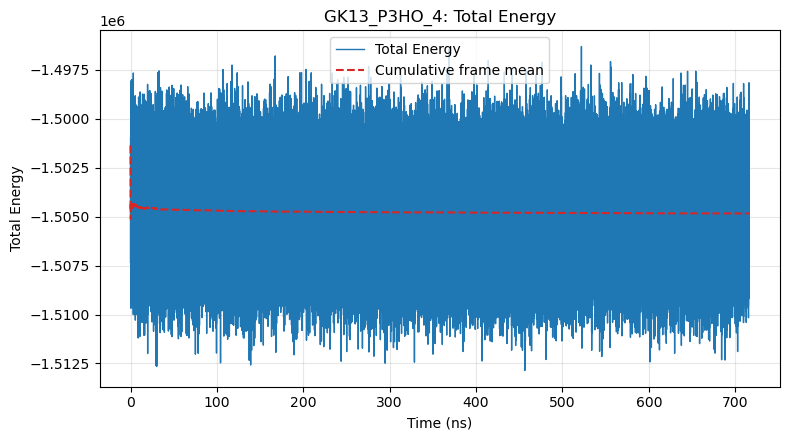

Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/total_energy.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/total_energy.png


In [4]:
# plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(energy_df["time_ns"], energy_df["total_energy"], linewidth=1.0, label="Total Energy")
ax.plot(energy_df["time_ns"], energy_df["cumulative_mean_energy"], color="tab:red", linestyle="--", linewidth=1.5, label="Cumulative frame mean")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Total Energy")
ax.set_title(f"{SYSTEM_NAME}: Total Energy")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(TOTAL_ENERGY_PNG, dpi=400)
plt.show()

print(f"Wrote: {TOTAL_ENERGY_CSV}")
print(f"Wrote: {TOTAL_ENERGY_PNG}")

## 5. Catalytic residue detection

In [5]:
try:
    import MDAnalysis as mda
    from MDAnalysis.lib.distances import distance_array
except ImportError as exc:
    raise ImportError("MDAnalysis is required for the contact-map section. Install or load it before running this notebook.") from exc


def catalytic_residue_definitions(system_name: str) -> list[tuple[str, int]]:
    if system_name.startswith("GK13"):
        return [
            ("SER", 139),
            ("ASP", 195),
            ("HIS", 227),
        ]
    if system_name.startswith("ANC45"):
        return [
            ("SER", 138),
            ("ASP", 194),
            ("HIS", 226),
        ]
    raise ValueError(
        f"No catalytic-residue definition is configured for SYSTEM_NAME={system_name!r}. "
        "Expected a name starting with 'GK13' or 'Anc45'."
    )


def load_universe_with_fallback():
    attempts = []
    for topology_path in (TPR_PATH, GRO_PATH):
        if not topology_path.exists():
            attempts.append(f"{topology_path}: file does not exist")
            continue
        try:
            universe = mda.Universe(str(topology_path), str(XTC_PATH))
            return universe, topology_path
        except Exception as exc:
            attempts.append(f"{topology_path}: {type(exc).__name__}: {exc}")
    raise RuntimeError("MDAnalysis could not load the trajectory with TPR_PATH or GRO_PATH.\n" + "\n".join(attempts))


u, topology_used = load_universe_with_fallback()
print(f"Loaded topology: {topology_used}")
print(f"Loaded trajectory: {XTC_PATH}")
print(f"Atoms: {u.atoms.n_atoms}")
print(f"Frames: {len(u.trajectory)}")

catalytic_residues = catalytic_residue_definitions(SYSTEM_NAME)
catalytic_residues

/opt/homebrew/Caskroom/miniconda/base/envs/ipha_clean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded topology: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step6.2_npt.tpr
Loaded trajectory: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/production_combined_003.xtc
Atoms: 137360
Frames: 7160


[('SER', 139), ('ASP', 195), ('HIS', 227)]

In [6]:
CATALYTIC_RESIDUES_USED_CSV = OUTPUT_DIR / "catalytic_residues_used.csv"

HISTIDINE_RESNAMES = {"HIS", "HID", "HIE", "HIP", "HSD", "HSE", "HSP"}
COMPATIBLE_RESNAMES = {
    "SER": {"SER"},
    "ASP": {"ASP"},
    "HIS": HISTIDINE_RESNAMES,
}
SIDECHAIN_ATOMS = {
    "SER": {"OG"},
    "ASP": {"OD1", "OD2"},
    "HIS": {"ND1", "NE2"},
}

protein_atoms = u.select_atoms("protein")
if len(protein_atoms) == 0:
    raise ValueError("MDAnalysis selection 'protein' returned no atoms. Check that the topology contains recognised protein residue names.")


def find_catalytic_residue(expected_resname: str, expected_resid: int):
    expected_resname = expected_resname.upper()
    compatible_names = COMPATIBLE_RESNAMES[expected_resname]
    same_resid = [residue for residue in protein_atoms.residues if int(residue.resid) == expected_resid]
    if not same_resid:
        raise ValueError(
            f"Expected catalytic residue {expected_resname}{expected_resid} was not found. "
            "Residue numbering may not match the topology."
        )
    compatible = [residue for residue in same_resid if residue.resname.upper() in compatible_names]
    if not compatible:
        observed = ", ".join(sorted({f"{res.resname}{res.resid}" for res in same_resid}))
        raise ValueError(
            f"Residue ID {expected_resid} was found as {observed}, not expected {expected_resname}. "
            "Residue numbering may not match the topology."
        )
    if len(compatible) > 1:
        observed = ", ".join(f"{res.resname}{res.resid} index={res.ix}" for res in compatible)
        raise ValueError(f"Multiple protein residues match {expected_resname}{expected_resid}: {observed}")
    return compatible[0]


def select_required_sidechain_atoms(residue, expected_resname: str):
    required_names = SIDECHAIN_ATOMS[expected_resname]
    selected_atoms = residue.atoms.select_atoms("name " + " ".join(sorted(required_names)))
    found_names = {atom.name.upper() for atom in selected_atoms}
    missing = sorted(required_names - found_names)
    if missing:
        raise ValueError(
            f"Missing required catalytic side-chain atom(s) {missing} in {residue.resname}{residue.resid}. "
            "Check atom naming in the topology before calculating distances."
        )
    return selected_atoms


catalytic_sites = []
catalytic_rows = []

for expected_resname, expected_resid in catalytic_residues:
    residue = find_catalytic_residue(expected_resname, expected_resid)
    analysis_atoms = select_required_sidechain_atoms(residue, expected_resname)
    expected_label = f"{expected_resname}{expected_resid}"
    atom_names_used = " ".join(atom.name for atom in analysis_atoms)
    catalytic_sites.append(
        {
            "label": expected_label,
            "residue": residue,
            "analysis_atoms": analysis_atoms,
        }
    )
    catalytic_rows.append(
        {
            "expected_label": expected_label,
            "actual_resname": residue.resname,
            "actual_resid": int(residue.resid),
            "atom_names_used": atom_names_used,
            "n_atoms": int(analysis_atoms.n_atoms),
        }
    )

catalytic_df = pd.DataFrame(catalytic_rows)
catalytic_df.to_csv(CATALYTIC_RESIDUES_USED_CSV, index=False)
display(catalytic_df)
print(f"Wrote: {CATALYTIC_RESIDUES_USED_CSV}")

,expected_label,actual_resname,actual_resid,atom_names_used,n_atoms
0,SER139,SER,139,OG,1
1,ASP195,ASP,195,OD1 OD2,2
2,HIS227,HSD,227,ND1 NE2,2


Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/catalytic_residues_used.csv


## 6. LIG polymer atom detection

In [7]:
POLYMER_RESIDUE_ATOM_INSPECTION_CSV = OUTPUT_DIR / "polymer_residue_atom_inspection.csv"
POLYMER_GROUPS_USED_CSV = OUTPUT_DIR / "polymer_groups_used.csv"

polymer_atoms = u.select_atoms(POLYMER_SELECTION)
if len(polymer_atoms) == 0:
    raise ValueError(
        "The polymer selection returned no atoms. Check POLYMER_SELECTION and the topology residue names. "
        f"Current selection: {POLYMER_SELECTION!r}"
    )

polymer_residues = list(polymer_atoms.residues)
polymer_inspection_rows = [
    {
        "resid": int(residue.resid),
        "resname": residue.resname,
        "atom_names": " ".join(atom.name for atom in residue.atoms),
        "n_atoms": int(residue.atoms.n_atoms),
    }
    for residue in polymer_residues
]
polymer_inspection_df = pd.DataFrame(polymer_inspection_rows)
polymer_inspection_df.to_csv(POLYMER_RESIDUE_ATOM_INSPECTION_CSV, index=False)

print(f"Polymer selection: {POLYMER_SELECTION}")
print(f"Polymer atoms: {polymer_atoms.n_atoms}")
print(f"Polymer residues: {len(polymer_residues)}")
display(polymer_inspection_df)
print(f"Wrote: {POLYMER_RESIDUE_ATOM_INSPECTION_CSV}")


def normalise_override_resids(value, label: str):
    if value is None:
        return None
    if isinstance(value, int):
        return [value]
    try:
        return [int(resid) for resid in value]
    except TypeError as exc:
        raise TypeError(f"{label} must be None, an int, or an iterable of residue IDs.") from exc


def infer_lig_atom_order_groups(lig_atoms):
    n_atoms = lig_atoms.n_atoms
    if n_atoms < 3:
        raise ValueError("At least three LIG atoms are needed to infer polymer_head, polymer_main, and polymer_tail.")
    first_cut = n_atoms // 3
    second_cut = (2 * n_atoms) // 3
    if first_cut == 0 or second_cut <= first_cut or second_cut >= n_atoms:
        raise ValueError("Could not split LIG atoms into non-empty head, main, and tail groups.")
    return {
        "polymer_head": lig_atoms[:first_cut],
        "polymer_main": lig_atoms[first_cut:second_cut],
        "polymer_tail": lig_atoms[second_cut:],
    }


def select_polymer_atoms_by_resids(group_resids, group_name: str):
    group_resids = [int(resid) for resid in group_resids]
    polymer_atom_resids = polymer_atoms.resids.astype(int)
    group_atoms = polymer_atoms[np.isin(polymer_atom_resids, np.array(group_resids, dtype=int))]
    if len(group_atoms) == 0:
        raise ValueError(f"{group_name} contains no LIG atoms for residue IDs {group_resids}.")
    return group_atoms

manual_groups = {
    "polymer_head": normalise_override_resids(POLYMER_HEAD_RESIDS, "POLYMER_HEAD_RESIDS"),
    "polymer_main": normalise_override_resids(POLYMER_MAIN_RESIDS, "POLYMER_MAIN_RESIDS"),
    "polymer_tail": normalise_override_resids(POLYMER_TAIL_RESIDS, "POLYMER_TAIL_RESIDS"),
}

if all(value is None for value in manual_groups.values()):
    polymer_groups = infer_lig_atom_order_groups(polymer_atoms)
    group_source = "automatic_lig_atom_order_thirds"
elif all(value is not None for value in manual_groups.values()):
    polymer_groups = {
        group_name: select_polymer_atoms_by_resids(group_resids, group_name)
        for group_name, group_resids in manual_groups.items()
    }
    group_source = "manual_override"
else:
    raise ValueError(
        "Set all three polymer group overrides, or leave all three as None: "
        "POLYMER_HEAD_RESIDS, POLYMER_MAIN_RESIDS, POLYMER_TAIL_RESIDS."
    )

polymer_group_rows = []

for group_name, group_atoms in polymer_groups.items():
    group_resids = list(dict.fromkeys(int(resid) for resid in group_atoms.resids))
    polymer_group_rows.append(
        {
            "group_name": group_name,
            "resids": " ".join(str(resid) for resid in group_resids),
            "n_atoms": int(group_atoms.n_atoms),
            "atom_names": " ".join(atom.name for atom in group_atoms),
        }
    )

polymer_groups_df = pd.DataFrame(polymer_group_rows)
polymer_groups_df.to_csv(POLYMER_GROUPS_USED_CSV, index=False)
print(f"Polymer group detection: {group_source}")
print("Final polymer groups used for distance calculation:")
display(polymer_groups_df)
print(f"Wrote: {POLYMER_GROUPS_USED_CSV}")

Polymer selection: resname LIG
Polymer atoms: 99
Polymer residues: 1


,resid,resname,atom_names,n_atoms
0,246,LIG,C16 C15 O4 H28 H29 C9 O3 H16 C8 C7 O2 H14 H15 ...,99


Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/polymer_residue_atom_inspection.csv
Polymer group detection: automatic_lig_atom_order_thirds
Final polymer groups used for distance calculation:


,group_name,resids,n_atoms,atom_names
0,polymer_head,246,33,C16 C15 O4 H28 H29 C9 O3 H16 C8 C7 O2 H14 H15 ...
1,polymer_main,246,33,C10 C11 H17 H18 H19 H20 C12 C13 H21 H22 H23 H2...
2,polymer_tail,246,33,H40 H41 C23 C24 H42 H43 O6 O7 C25 H44 C26 C27 ...


Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/polymer_groups_used.csv


# Question 1 — Has the simulation reached a stable state, or should it be extended?

Use protein backbone RMSD as the primary global-stability measurement and protein-aligned polymer RMSD to assess polymer motion relative to the enzyme. Total Energy is retained only as a diagnostic for abnormal drift or simulation problems.

Inspect the plots and compact final-20% statistics manually. This section does not automatically decide whether the trajectory must be extended, and catalytic-residue/polymer contacts remain a separate later question.

## RMSD selections and shared helpers

The protein-aligned measurements use only protein backbone atoms named N, CA, and C for alignment. Polymer RMSD uses LIG heavy atoms and does not align the polymer separately.

In [8]:
from MDAnalysis.analysis import align, rms

PROTEIN_BACKBONE_SELECTION = "protein and name N CA C"
POLYMER_HEAVY_SELECTION = f"({POLYMER_SELECTION}) and not name H*"
RMSD_ROLLING_WINDOW_FRAMES = 100  # Set to None to disable the optional rolling mean.

protein_backbone = u.select_atoms(PROTEIN_BACKBONE_SELECTION)
polymer_heavy_atoms = u.select_atoms(POLYMER_HEAVY_SELECTION)

for selection_label, atom_group in {
    "protein backbone (N, CA, C)": protein_backbone,
    "polymer heavy atoms": polymer_heavy_atoms,
}.items():
    print(f"{selection_label}: {atom_group.n_atoms} atoms selected")
    if atom_group.n_atoms == 0:
        raise ValueError(f"The {selection_label!r} selection contains no atoms.")

reference_u, reference_topology_used = load_universe_with_fallback()
reference_u.trajectory[0]
reference_backbone = reference_u.select_atoms(PROTEIN_BACKBONE_SELECTION)
reference_polymer_heavy = reference_u.select_atoms(POLYMER_HEAVY_SELECTION)

if reference_backbone.n_atoms != protein_backbone.n_atoms:
    raise ValueError("Mobile and reference protein-backbone selections contain different atom counts.")
if reference_polymer_heavy.n_atoms != polymer_heavy_atoms.n_atoms:
    raise ValueError("Mobile and reference polymer-heavy-atom selections contain different atom counts.")

print(f"Reference topology: {reference_topology_used}")
print(f"Reference frame: {reference_u.trajectory.frame}")


def trajectory_row(ts, value_column: str, value: float) -> dict:
    time_ps = float(ts.time)
    return {
        "frame": int(ts.frame),
        "time_ps": time_ps,
        "time_ns": time_ps / 1000.0,
        value_column: float(value),
    }


def compact_rmsd_statistics(values) -> dict:
    series = pd.Series(values, dtype=float).dropna().reset_index(drop=True)
    if series.empty:
        raise ValueError("Cannot summarise an empty RMSD series.")
    final_count = max(1, int(np.ceil(0.20 * len(series))))
    final_window = series.iloc[-final_count:]
    return {
        "mean_A": float(series.mean()),
        "std_A": float(series.std(ddof=1)),
        "final_20_percent_mean_A": float(final_window.mean()),
        "final_20_percent_std_A": float(final_window.std(ddof=1)),
    }


def save_rmsd_outputs(
    metric_df,
    value_column: str,
    csv_path: Path,
    png_path: Path,
    ylabel: str,
    title: str,
    rolling_window_frames: int | None = None,
):
    if metric_df.empty:
        raise ValueError(f"No values were calculated for {value_column}.")
    values = metric_df[value_column].to_numpy(dtype=float)
    if not np.all(np.isfinite(values)):
        raise ValueError(f"Non-finite values were calculated for {value_column}.")

    plot_df = metric_df.copy()
    rolling_column = None
    if rolling_window_frames is not None:
        if rolling_window_frames < 1:
            raise ValueError("rolling_window_frames must be at least 1 or None.")
        rolling_column = f"{value_column}_rolling_mean"
        plot_df[rolling_column] = plot_df[value_column].rolling(
            rolling_window_frames, min_periods=1
        ).mean()

    plot_df.to_csv(csv_path, index=False)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(plot_df["time_ns"], plot_df[value_column], linewidth=0.8, alpha=0.55, label="Raw RMSD")
    if rolling_column is not None:
        ax.plot(
            plot_df["time_ns"],
            plot_df[rolling_column],
            linewidth=1.8,
            label=f"Rolling mean ({rolling_window_frames} frames)",
        )
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(png_path, dpi=400)
    plt.show()

    stats = compact_rmsd_statistics(plot_df[value_column])
    print(f"Mean RMSD: {stats['mean_A']:.4f} Å")
    print(f"RMSD standard deviation: {stats['std_A']:.4f} Å")
    print(f"Final 20% mean RMSD: {stats['final_20_percent_mean_A']:.4f} Å")
    print(f"Final 20% RMSD standard deviation: {stats['final_20_percent_std_A']:.4f} Å")
    print(f"Wrote: {csv_path}")
    print(f"Wrote: {png_path}")
    return stats

protein backbone (N, CA, C): 735 atoms selected
polymer heavy atoms: 41 atoms selected
Reference topology: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/step6.2_npt.tpr
Reference frame: 0


## Protein backbone RMSD

Each frame is aligned to the first trajectory frame using protein backbone atoms N, CA, and C. The reported backbone RMSD therefore measures protein structural deviation after removing overall translation and rotation.

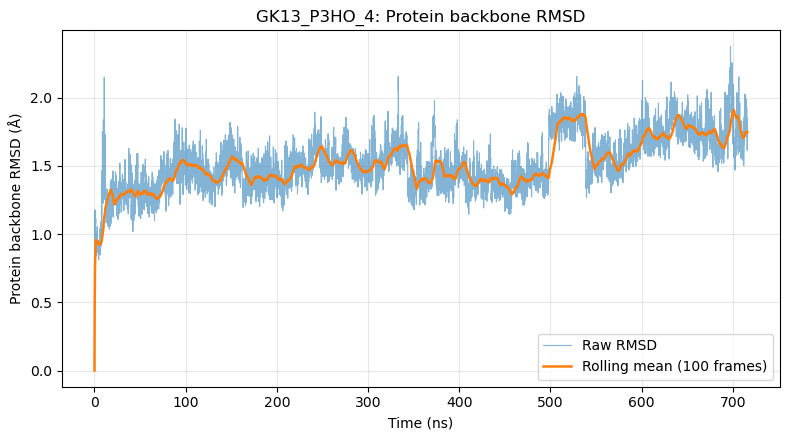

Mean RMSD: 1.5205 Å
RMSD standard deviation: 0.1997 Å
Final 20% mean RMSD: 1.7293 Å
Final 20% RMSD standard deviation: 0.1356 Å
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/protein_backbone_rmsd.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/protein_backbone_rmsd.png


In [9]:
PROTEIN_BACKBONE_RMSD_CSV = OUTPUT_DIR / "protein_backbone_rmsd.csv"
PROTEIN_BACKBONE_RMSD_PNG = OUTPUT_DIR / "protein_backbone_rmsd.png"

protein_backbone_rmsd_rows = []
reference_u.trajectory[0]
for ts in u.trajectory:
    align.alignto(u, reference_u, select=PROTEIN_BACKBONE_SELECTION, weights=None)
    backbone_rmsd_A = rms.rmsd(
        protein_backbone.positions,
        reference_backbone.positions,
        center=False,
        superposition=False,
    )
    protein_backbone_rmsd_rows.append(trajectory_row(ts, "protein_backbone_rmsd_A", backbone_rmsd_A))

protein_backbone_rmsd_df = pd.DataFrame(protein_backbone_rmsd_rows)
protein_backbone_rmsd_stats = save_rmsd_outputs(
    protein_backbone_rmsd_df,
    "protein_backbone_rmsd_A",
    PROTEIN_BACKBONE_RMSD_CSV,
    PROTEIN_BACKBONE_RMSD_PNG,
    "Protein backbone RMSD (Å)",
    f"{SYSTEM_NAME}: Protein backbone RMSD",
    rolling_window_frames=RMSD_ROLLING_WINDOW_FRAMES,
)

<!-- Protein radius of gyration is intentionally disabled for the focused Question 1 analysis. -->

## Polymer RMSD relative to the protein

Every trajectory frame is first aligned to the first frame using the protein backbone. Polymer heavy-atom RMSD is then calculated without any separate polymer alignment. This measures whether the polymer remains in a similar position and orientation relative to the enzyme.

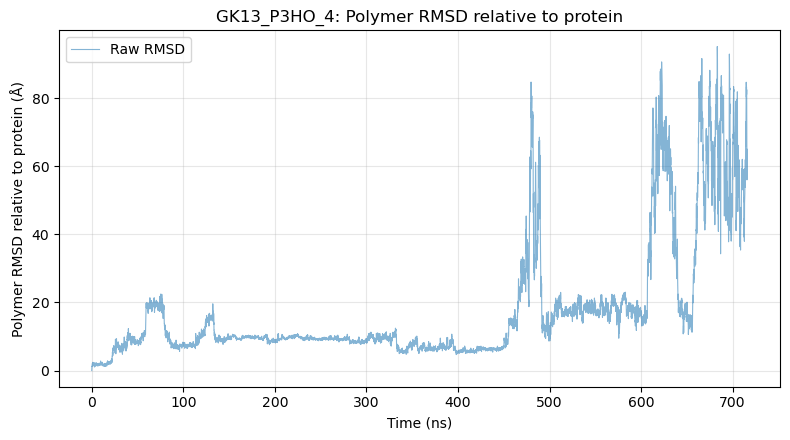

Mean RMSD: 17.8797 Å
RMSD standard deviation: 18.3752 Å
Final 20% mean RMSD: 44.0480 Å
Final 20% RMSD standard deviation: 23.6803 Å
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/polymer_rmsd_relative_to_protein.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/polymer_rmsd_relative_to_protein.png


In [13]:
POLYMER_RELATIVE_RMSD_CSV = OUTPUT_DIR / "polymer_rmsd_relative_to_protein.csv"
POLYMER_RELATIVE_RMSD_PNG = OUTPUT_DIR / "polymer_rmsd_relative_to_protein.png"

polymer_relative_rmsd_rows = []
reference_u.trajectory[0]
for ts in u.trajectory:
    align.alignto(u, reference_u, select=PROTEIN_BACKBONE_SELECTION, weights=None)
    polymer_relative_rmsd_A = rms.rmsd(
        polymer_heavy_atoms.positions,
        reference_polymer_heavy.positions,
        center=False,
        superposition=False,
    )
    polymer_relative_rmsd_rows.append(
        trajectory_row(ts, "polymer_relative_to_protein_rmsd_A", polymer_relative_rmsd_A)
    )

polymer_relative_rmsd_df = pd.DataFrame(polymer_relative_rmsd_rows)
polymer_relative_rmsd_stats = save_rmsd_outputs(
    polymer_relative_rmsd_df,
    "polymer_relative_to_protein_rmsd_A",
    POLYMER_RELATIVE_RMSD_CSV,
    POLYMER_RELATIVE_RMSD_PNG,
    "Polymer RMSD relative to protein (Å)",
    f"{SYSTEM_NAME}: Polymer RMSD relative to protein",
)

## Compact manual interpretation

Use the two RMSD plots, their compact statistics, and the Total Energy plot to record a manual conclusion. Total Energy is only a diagnostic for abnormal drift or simulation problems and cannot establish structural stability by itself.

In [14]:
print("Compact manual interpretation")
print("- Protein RMSD: appears plateaued / still drifting (choose after inspecting the raw and rolling-mean curves).")
print("- Polymer RMSD: appears plateaued / still drifting (choose after inspecting the protein-aligned curve).")
print("- Total Energy: no obvious abnormal drift / possible drift (choose after inspecting the diagnostic plot).")
print("- Manual conclusion: extend simulation / current trajectory is probably sufficient.")
print("No conclusion is selected automatically.")

Compact manual interpretation
- Protein RMSD: appears plateaued / still drifting (choose after inspecting the raw and rolling-mean curves).
- Polymer RMSD: appears plateaued / still drifting (choose after inspecting the protein-aligned curve).
- Total Energy: no obvious abnormal drift / possible drift (choose after inspecting the diagnostic plot).
- Manual conclusion: extend simulation / current trajectory is probably sufficient.
No conclusion is selected automatically.


Protein backbone RMSD is the primary global-stability measurement. Protein-aligned polymer RMSD indicates whether the polymer remains in a similar position relative to the enzyme. Total Energy is only a diagnostic for abnormal drift or simulation problems. Catalytic-residue/polymer contacts answer a separate later question.

## 7. Contact calculation

For each frame, calculate the minimum distance between each catalytic residue side-chain atom set and each LIG polymer group: `polymer_head`, `polymer_main`, and `polymer_tail`.

By default, the LIG atoms are split by topology order: beginning = `polymer_head`, middle = `polymer_main`, end = `polymer_tail`.

MDAnalysis normally loads GROMACS coordinates in Å internally, so the cutoff is used directly as `CUTOFF_ANGSTROM = 3.0`.

The contact heatmap depends strongly on this cutoff, so the minimum-distance and mean-distance matrices are saved as more diagnostic summaries alongside contact occupancy.

In [15]:
CATALYTIC_TRIAD_POLYMER_DISTANCES_CSV = OUTPUT_DIR / "catalytic_triad_polymer_distances.csv"
CATALYTIC_TRIAD_POLYMER_CONTACT_OCCUPANCY_CSV = OUTPUT_DIR / "catalytic_triad_polymer_contact_occupancy.csv"
CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_CSV = OUTPUT_DIR / "catalytic_triad_polymer_min_distance.csv"
CATALYTIC_TRIAD_POLYMER_MEAN_DISTANCE_CSV = OUTPUT_DIR / "catalytic_triad_polymer_mean_distance.csv"

catalytic_order = [site["label"] for site in catalytic_sites]
polymer_group_order = ["polymer_head", "polymer_main", "polymer_tail"]

distance_rows = []

for ts in u.trajectory:
    for site in catalytic_sites:
        for group_name in polymer_group_order:
            group_atoms = polymer_groups[group_name]
            distances = distance_array(site["analysis_atoms"].positions, group_atoms.positions, box=ts.dimensions)
            min_distance = float(np.min(distances))
            distance_rows.append(
                {
                    "frame": int(ts.frame),
                    "time_ps": float(ts.time),
                    "catalytic_residue": site["label"],
                    "polymer_group": group_name,
                    "min_distance_A": min_distance,
                    "contact": min_distance <= CUTOFF_ANGSTROM,
                }
            )

distances_df = pd.DataFrame(distance_rows)
if distances_df.empty:
    raise ValueError("No distance rows were calculated. Check that the trajectory contains frames.")

distances_df.to_csv(CATALYTIC_TRIAD_POLYMER_DISTANCES_CSV, index=False)

occupancy_matrix = (
    distances_df.groupby(["catalytic_residue", "polymer_group"])["contact"]
    .mean()
    .unstack("polymer_group")
    .reindex(index=catalytic_order, columns=polymer_group_order)
)
occupancy_matrix.to_csv(CATALYTIC_TRIAD_POLYMER_CONTACT_OCCUPANCY_CSV)

min_distance_matrix = (
    distances_df.groupby(["catalytic_residue", "polymer_group"])["min_distance_A"]
    .min()
    .unstack("polymer_group")
    .reindex(index=catalytic_order, columns=polymer_group_order)
)
min_distance_matrix.to_csv(CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_CSV)

mean_distance_matrix = (
    distances_df.groupby(["catalytic_residue", "polymer_group"])["min_distance_A"]
    .mean()
    .unstack("polymer_group")
    .reindex(index=catalytic_order, columns=polymer_group_order)
)
mean_distance_matrix.to_csv(CATALYTIC_TRIAD_POLYMER_MEAN_DISTANCE_CSV)

print(f"Analysed frames: {distances_df['frame'].nunique()}")
display(distances_df.head())
print("Contact occupancy matrix:")
display(occupancy_matrix)
print("Minimum distance matrix (Å):")
display(min_distance_matrix)
print("Mean distance matrix (Å):")
display(mean_distance_matrix)
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_DISTANCES_CSV}")
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_CONTACT_OCCUPANCY_CSV}")
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_CSV}")
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_MEAN_DISTANCE_CSV}")

Analysed frames: 7160


,frame,time_ps,catalytic_residue,polymer_group,min_distance_A,contact
0,0,0.0,SER139,polymer_head,1.836653,True
1,0,0.0,SER139,polymer_main,4.254631,False
2,0,0.0,SER139,polymer_tail,3.177626,False
3,0,0.0,ASP195,polymer_head,7.042258,False
4,0,0.0,ASP195,polymer_main,6.729599,False


Contact occupancy matrix:


polymer_group,polymer_head,polymer_main,polymer_tail
catalytic_residue,,,
SER139,0.091760,0.112430,0.157123
ASP195,0.000279,0.000000,0.000000
HIS227,0.035615,0.021229,0.066201


Minimum distance matrix (Å):


polymer_group,polymer_head,polymer_main,polymer_tail
catalytic_residue,,,
SER139,1.676242,2.266053,1.747455
ASP195,2.327442,3.558175,3.268672
HIS227,1.844611,2.353039,1.838097


Mean distance matrix (Å):


polymer_group,polymer_head,polymer_main,polymer_tail
catalytic_residue,,,
SER139,14.978128,14.051543,14.007784
ASP195,17.716506,17.234906,17.372988
HIS227,15.462048,14.867898,14.748496


Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_distances.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_contact_occupancy.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_min_distance.csv
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_mean_distance.csv


## 8. Contact and minimum-distance heatmaps

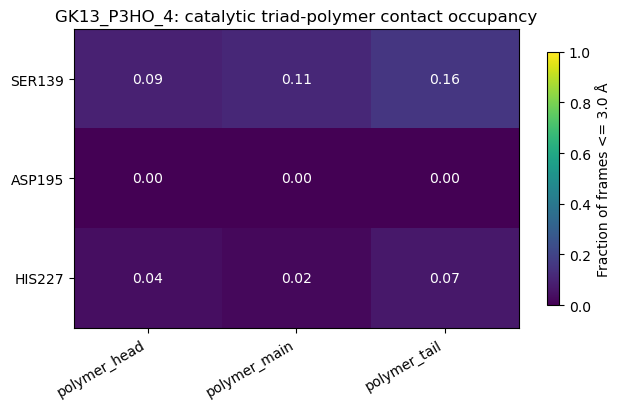

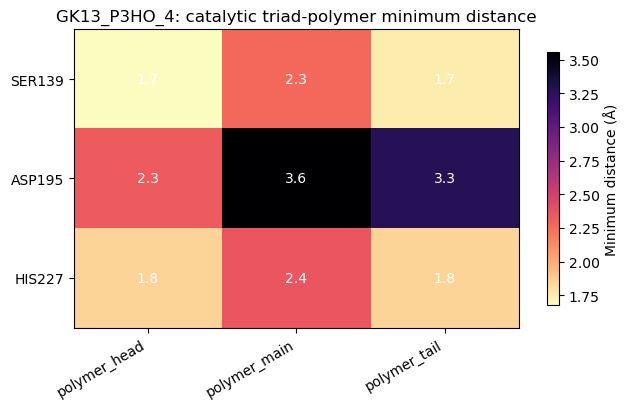

Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_contact_heatmap.png
Wrote: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_Enzyme/GK13_P3HO_4_gromacs/analysis/enzyme_polymer_analysis/catalytic_triad_polymer_min_distance_heatmap.png


In [16]:
CATALYTIC_TRIAD_POLYMER_CONTACT_HEATMAP_PNG = OUTPUT_DIR / "catalytic_triad_polymer_contact_heatmap.png"
CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_HEATMAP_PNG = OUTPUT_DIR / "catalytic_triad_polymer_min_distance_heatmap.png"

fig, ax = plt.subplots(figsize=(6.5, 4.2))
image = ax.imshow(occupancy_matrix.to_numpy(dtype=float), vmin=0.0, vmax=1.0, cmap="viridis", aspect="auto")
ax.set_xticks(np.arange(len(polymer_group_order)))
ax.set_xticklabels(polymer_group_order, rotation=30, ha="right")
ax.set_yticks(np.arange(len(catalytic_order)))
ax.set_yticklabels(catalytic_order)
ax.set_title(f"{SYSTEM_NAME}: catalytic triad-polymer contact occupancy")

for row_index, residue_label in enumerate(catalytic_order):
    for column_index, group_name in enumerate(polymer_group_order):
        value = occupancy_matrix.loc[residue_label, group_name]
        text_color = "white" if value < 0.55 else "black"
        ax.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", color=text_color)

colorbar = fig.colorbar(image, ax=ax, shrink=0.85)
colorbar.set_label(f"Fraction of frames <= {CUTOFF_ANGSTROM:.1f} Å")
fig.tight_layout()
fig.savefig(CATALYTIC_TRIAD_POLYMER_CONTACT_HEATMAP_PNG, dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.2))
min_values = min_distance_matrix.to_numpy(dtype=float)
image = ax.imshow(min_values, cmap="magma_r", aspect="auto")
ax.set_xticks(np.arange(len(polymer_group_order)))
ax.set_xticklabels(polymer_group_order, rotation=30, ha="right")
ax.set_yticks(np.arange(len(catalytic_order)))
ax.set_yticklabels(catalytic_order)
ax.set_title(f"{SYSTEM_NAME}: catalytic triad-polymer minimum distance")

for row_index, residue_label in enumerate(catalytic_order):
    for column_index, group_name in enumerate(polymer_group_order):
        value = min_distance_matrix.loc[residue_label, group_name]
        ax.text(column_index, row_index, f"{value:.1f}", ha="center", va="center", color="white")

colorbar = fig.colorbar(image, ax=ax, shrink=0.85)
colorbar.set_label("Minimum distance (Å)")
fig.tight_layout()
fig.savefig(CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_HEATMAP_PNG, dpi=200)
plt.show()

print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_CONTACT_HEATMAP_PNG}")
print(f"Wrote: {CATALYTIC_TRIAD_POLYMER_MIN_DISTANCE_HEATMAP_PNG}")

## 9. Short interpretation

In [17]:
print("Short interpretation")
print("- Contact occupancy is the fraction of analysed frames where the catalytic residue is within the cutoff of a polymer group.")
print("- The contact heatmap depends strongly on the cutoff, so inspect the minimum-distance and mean-distance matrices before interpreting occupancy.")
print("- Treat Total Energy as a first diagnostic only; in NVT/NPT it is not expected to be perfectly conserved, but strong drift or sudden jumps suggest a problem.")

Short interpretation
- Contact occupancy is the fraction of analysed frames where the catalytic residue is within the cutoff of a polymer group.
- The contact heatmap depends strongly on the cutoff, so inspect the minimum-distance and mean-distance matrices before interpreting occupancy.
- Treat Total Energy as a first diagnostic only; in NVT/NPT it is not expected to be perfectly conserved, but strong drift or sudden jumps suggest a problem.
